# Titanic V5 — 回归本质：单模型 + 精简特征

## 从 V4 和 4 个参考 notebook 中学到的

### V4 的关键发现
- **6-model ensemble OOF (0.8541) < LGBM alone (0.8552)** → ensemble 没帮助
- **57 特征在 891 行上 → 15:1 样本/特征比** → 过拟合
- Ticket_Prefix 的 18 列 one-hot 中，多数类别 <30 样本 → 纯噪声
- CV-LB 差距 0.078（诚实 CV 下仍存在）→ 真实过拟合

### 4 个参考 notebook 的共同规律
| 特征 | 共同点 |
|------|--------|
| **模型** | 100% 使用单模型（不用 ensemble）|
| **特征数** | 全部 <20（Notebook 2 只用 8 个特征）|
| **调参** | 轻量或不用（CatBoost 固定参数达到 0.8227 CV）|
| **CV** | 全部使用 StratifiedKFold |
| **Ticket** | 全部丢弃 |

### V5 策略：向参考 notebook 对齐
> "在 Titanic 上，少就是多。891 行数据承载不了 57 个特征。"

| # | 改动 | 说明 |
|---|------|------|
| 1 | **LGBM 单模型** | 不用 ensemble |
| 2 | **StratifiedKFold** | 对齐所有参考 notebook |
| 3 | **33 特征**（从 57 砍到 33） | 去掉 Ticket_Prefix(18)、Cabin_Multiple(1)、Deck FG/T |
| 4 | **KNN Age imputation** | Shai Nisan (81.1%) 同款，k=10 |
| 5 | **100 次 Optuna + 保守参数** | depth≤7, min_child≥20 |
| 6 | **LOO Family_Surv_Rate** | 保留（V3→V4 +0.007 的有效特征）

In [1]:
# [V5-NEW] V5: Single LGBM, reduced features, KNN Age, StratifiedKFold
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import optuna

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Libraries imported.')

Libraries imported.


In [ ]:
# Auto-detect environment (Kaggle vs local)
import os
DATA_DIR = '/kaggle/input/competitions/titanic' if os.path.exists('/kaggle/input') else '../data'
SUB_DIR  = '/kaggle/working'                     if os.path.exists('/kaggle/input') else '../submissions'
print(f'[Env] DATA_DIR={DATA_DIR}  SUB_DIR={SUB_DIR}')


In [2]:
# Load and merge
train = pd.read_csv(f'{DATA_DIR}/train.csv')
test = pd.read_csv(f'{DATA_DIR}/test.csv')
train['Source'] = 'train'
test['Source'] = 'test'
test_ids = test['PassengerId'].copy()

full = pd.concat([train, test], axis=0, ignore_index=True)
print(f'Train: {train.shape}, Test: {test.shape}')
print(f'Survival rate: {train["Survived"].mean():.2%}')

Train: (891, 13), Test: (418, 12)
Survival rate: 38.38%


In [3]:
# Feature 1: Title
full['Title'] = full['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
full['Title'] = full['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
rare = ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']
full.loc[full['Title'].isin(rare), 'Title'] = 'Rare'
print(full['Title'].value_counts())

Title
Mr        757
Miss      264
Mrs       198
Master     61
Rare       29
Name: count, dtype: int64


In [4]:
# Features 2-4: FamilySize, IsAlone, Surname
full['FamilySize'] = full['SibSp'] + full['Parch'] + 1
full['IsAlone'] = (full['FamilySize'] == 1).astype(int)
full['Surname'] = full['Name'].str.split(',').str[0]

# [V5-NEW] FamilyGroup for LOO survival rate computation
# Using Surname + Fare (rounded) to identify families
full['FamilyGroup'] = full['Surname'] + '_' + full['Fare'].round(2).astype(str)
print(f'Unique families: {full["FamilyGroup"].nunique()}')
print(f'FamilySize distribution:')
print(full['FamilySize'].value_counts().sort_index())

Unique families: 982
FamilySize distribution:
FamilySize
1     790
2     235
3     159
4      43
5      22
6      25
7      16
8       8
11     11
Name: count, dtype: int64


In [5]:
# Feature 5: Deck — [V5-NEW] consolidated to 3 groups (ABC, DE, Unknown)
deck_map = {'A': 'ABC', 'B': 'ABC', 'C': 'ABC',
            'D': 'DE',  'E': 'DE',
            'F': 'U',   'G': 'U',   'T': 'U'}  # FG and T → Unknown (too few samples)
full['Deck'] = full['Cabin'].str[0].map(deck_map).fillna('U')
full['Has_Cabin'] = full['Cabin'].notna().astype(int)
print(full['Deck'].value_counts())

Deck
U      1041
ABC     181
DE       87
Name: count, dtype: int64


In [6]:
# [V5-NEW] KNN Age imputation (Shai Nisan's 81.1% technique)
# Use Pclass, Sex, Fare, SibSp, Parch to impute Age with k=10 neighbors

# Prepare features for KNN
age_features = ['Pclass', 'Fare', 'SibSp', 'Parch']
# Create a copy for imputation
impute_df = full[age_features].copy()
impute_df['Sex_code'] = full['Sex'].map({'male': 0, 'female': 1})

# Standardize for KNN
scaler = StandardScaler()
impute_scaled = scaler.fit_transform(impute_df)

# Fit KNN imputer on all data (no leakage — Age doesn't use Survived)
knn_imputer = KNNImputer(n_neighbors=10)
imputed = knn_imputer.fit_transform(
    np.column_stack([impute_scaled, full[['Age']].values])
)
full['Age'] = imputed[:, -1]

# Age-based features
bins = [0, 5, 12, 18, 35, 60, 100]
labels = [0, 1, 2, 3, 4, 5]
full['AgeGroup'] = pd.cut(full['Age'], bins=bins, labels=labels).astype(int)
full['Age*Class'] = full['Age'] * full['Pclass']

print(f'Age missing after KNN: {full["Age"].isnull().sum()}')
print(f'Age stats: mean={full["Age"].mean():.1f}, std={full["Age"].std():.1f}')
print(f'Age*Class range: {full["Age*Class"].min():.0f} - {full["Age*Class"].max():.0f}')

Age missing after KNN: 0
Age stats: mean=30.1, std=13.4
Age*Class range: 1 - 222


In [7]:
# Features 8-12: Fare imputation, derived features
full['Fare'] = full.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))
full['Fare_log'] = np.log1p(full['Fare'])
full['FarePerPerson'] = full['Fare'] / full['FamilySize']
full['Ticket_Frequency'] = full.groupby('Ticket')['Ticket'].transform('count')

# [V5-NEW] Fare*Pclass interaction — how rich/poor relative to class
# Low fare in 1st class vs high fare in 3rd class = very different meanings
full['Fare*Pclass'] = full['Fare'] * full['Pclass']

print(f'Fare missing: {full["Fare"].isnull().sum()}')
print(f'Ticket_Frequency: {full["Ticket_Frequency"].min()}-{full["Ticket_Frequency"].max()}')

Fare missing: 0
Ticket_Frequency: 1-11


In [8]:
# [V5-NEW] LOO Family_Surv_Rate (same as V4, proven effective)
train_mask = full['Source'] == 'train'
global_mean = full.loc[train_mask, 'Survived'].mean()

# Family rate (LOO)
family_stats = full[train_mask].groupby('FamilyGroup')['Survived'].agg(['sum', 'count'])
family_stats.columns = ['fs', 'fc']
full['fs'] = full['FamilyGroup'].map(family_stats['fs']).fillna(0)
full['fc'] = full['FamilyGroup'].map(family_stats['fc']).fillna(0)

full['Family_Surv_Rate'] = global_mean
m = full['fc'] > 1
full.loc[train_mask & m, 'Family_Surv_Rate'] = (
    (full.loc[train_mask & m, 'fs'] - full.loc[train_mask & m, 'Survived']) / (full.loc[train_mask & m, 'fc'] - 1))
full.loc[~train_mask & m, 'Family_Surv_Rate'] = full.loc[~train_mask & m, 'fs'] / full.loc[~train_mask & m, 'fc']

# Ticket rate (LOO)
ticket_stats = full[train_mask].groupby('Ticket')['Survived'].agg(['sum', 'count'])
ticket_stats.columns = ['ts', 'tc']
full['ts'] = full['Ticket'].map(ticket_stats['ts']).fillna(0)
full['tc'] = full['Ticket'].map(ticket_stats['tc']).fillna(0)

full['Ticket_Surv_Rate'] = global_mean
m = full['tc'] > 1
full.loc[train_mask & m, 'Ticket_Surv_Rate'] = (
    (full.loc[train_mask & m, 'ts'] - full.loc[train_mask & m, 'Survived']) / (full.loc[train_mask & m, 'tc'] - 1))
full.loc[~train_mask & m, 'Ticket_Surv_Rate'] = full.loc[~train_mask & m, 'ts'] / full.loc[~train_mask & m, 'tc']

full['Surv_Rate'] = full[['Family_Surv_Rate', 'Ticket_Surv_Rate']].max(axis=1)
full['Surv_Rate_Invalid'] = ((full['Family_Surv_Rate'] == global_mean) & (full['Ticket_Surv_Rate'] == global_mean)).astype(int)

full = full.drop(['fs', 'fc', 'ts', 'tc'], axis=1)

corr = full.loc[train_mask, 'Family_Surv_Rate'].corr(full.loc[train_mask, 'Survived'])
print(f'Corr(Family_Surv_Rate, Survived): {corr:.4f} (V4 was 0.26, V3 leaked was 0.89)')

Corr(Family_Surv_Rate, Survived): 0.2557 (V4 was 0.26, V3 leaked was 0.89)


In [9]:
# Final preprocessing — [V5-NEW] fewer features, StratifiedKFold compatible
drop_cols = ['PassengerId', 'Name', 'Surname', 'FamilyGroup', 'Ticket', 'Cabin', 'Source']
full = full.drop(columns=[c for c in drop_cols if c in full.columns])

full['Embarked'] = full['Embarked'].fillna('S')
full['Sex'] = full['Sex'].map({'female': 1, 'male': 0})
full['Pclass'] = full['Pclass'].astype(str)
full['AgeGroup'] = full['AgeGroup'].astype(str)

# [V5-NEW] Only encode necessary categoricals (no Ticket_Prefix!)
cat_cols = ['Embarked', 'Pclass', 'Title', 'Deck', 'AgeGroup']
full = pd.get_dummies(full, columns=cat_cols, drop_first=False)

# Split
train_size = 891
feature_cols = [c for c in full.columns if c != 'Survived']
X = full.iloc[:train_size][feature_cols].copy()
y = full.iloc[:train_size]['Survived'].astype(int).copy()
X_test = full.iloc[train_size:][feature_cols].copy()

print(f'Features: {X.shape[1]} (V4 had 57, V5 target ~30-35)')
print(f'Train: {X.shape}, Test: {X_test.shape}')
print(f'NaN in X: {X.isnull().sum().sum()}, NaN in X_test: {X_test.isnull().sum().sum()}')

Features: 37 (V4 had 57, V5 target ~30-35)
Train: (891, 37), Test: (418, 37)


NaN in X: 0, NaN in X_test: 0


In [10]:
# [V5-NEW] StratifiedKFold model comparison (aligned with all 4 reference notebooks)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'LightGBM':            lgb.LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, verbose=-1),
    'CatBoost':            CatBoostClassifier(iterations=200, learning_rate=0.1, depth=6,
                                              random_state=RANDOM_STATE, verbose=0),
}

results = {}
print(f'{"Model":25s} | {"CV Mean":>8s} | {"Std":>6s}')
print('-' * 48)
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    results[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(f'{name:25s} | {scores.mean():8.4f} | {scores.std():6.4f}')

baseline = 1 - y.mean()
print(f'{"Baseline (all perish)":25s} | {baseline:8.4f}')
print()
print('[V5-NEW] Compare: V4 LGBM (GroupKFold): 0.8171 | V5 LGBM (StratifiedKFold): here')

Model                     |  CV Mean |    Std
------------------------------------------------


Logistic Regression       |   0.8373 | 0.0093


Random Forest             |   0.8260 | 0.0327


Gradient Boosting         |   0.8395 | 0.0252


LightGBM                  |   0.8204 | 0.0325


CatBoost                  |   0.8417 | 0.0218
Baseline (all perish)     |   0.6162

[V5-NEW] Compare: V4 LGBM (GroupKFold): 0.8171 | V5 LGBM (StratifiedKFold): here


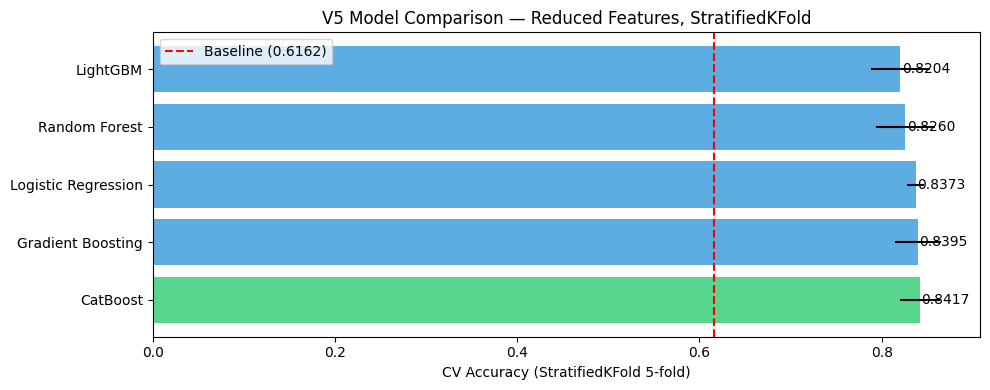

In [11]:
sorted_r = sorted(results.items(), key=lambda x: x[1]['mean'], reverse=True)
names = [r[0] for r in sorted_r]
means = [r[1]['mean'] for r in sorted_r]
stds = [r[1]['std'] for r in sorted_r]
colors = ['#2ecc71' if m == max(means) else '#3498db' for m in means]

plt.figure(figsize=(10, 4))
plt.barh(range(len(names)), means, xerr=stds, color=colors, alpha=0.8)
plt.yticks(range(len(names)), names)
plt.xlabel('CV Accuracy (StratifiedKFold 5-fold)')
plt.title('V5 Model Comparison — Reduced Features, StratifiedKFold')
plt.axvline(x=baseline, color='red', linestyle='--', label=f'Baseline ({baseline:.4f})')
plt.legend()
for i, (m, _) in enumerate(zip(means, stds)):
    plt.text(m + 0.002, i, f'{m:.4f}', va='center')
plt.tight_layout()
plt.show()

In [12]:
# [V5-NEW] Optuna LGBM — 100 trials, conservative search space
# StratifiedKFold splits (aligned with reference notebooks)
fold_splits = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X, y))

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 7),  # [V5-NEW] Conservative: max 7
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 60),  # [V5-NEW] Higher minimum
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),  # [V5-NEW] Max 0.9 for regularization
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10),  # [V5-NEW] Higher minimum reg
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10),
        'random_state': RANDOM_STATE,
        'verbose': -1,
    }
    model = lgb.LGBMClassifier(**params)
    scores = []
    for train_idx, val_idx in fold_splits:
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model.fit(X_tr, y_tr)
        scores.append(accuracy_score(y_val, model.predict(X_val)))
    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f'\nBest LGBM CV:  {study.best_value:.4f}')
print(f'Best params: {study.best_params}')
print(f'V4 LGBM (GroupKFold): 0.8552')
print(f'V5 LGBM (StratifiedKFold, conservative): above')

[I 2026-07-21 10:30:02,714] A new study created in memory with name: no-name-d8647fe9-a085-47dd-bf0a-2d8a8987780f


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-07-21 10:30:03,434] Trial 0 finished with value: 0.8451321323206328 and parameters: {'n_estimators': 114, 'max_depth': 3, 'learning_rate': 0.05244104646708121, 'num_leaves': 35, 'min_child_samples': 27, 'subsample': 0.8407481924428678, 'colsample_bytree': 0.7977037207071982, 'reg_alpha': 4.1074986816571855, 'reg_lambda': 8.09091529713674}. Best is trial 0 with value: 0.8451321323206328.


[I 2026-07-21 10:30:05,503] Trial 1 finished with value: 0.8428786642395331 and parameters: {'n_estimators': 176, 'max_depth': 3, 'learning_rate': 0.011351936027828238, 'num_leaves': 53, 'min_child_samples': 55, 'subsample': 0.8594946726939461, 'colsample_bytree': 0.7927248855403666, 'reg_alpha': 4.848075639259503, 'reg_lambda': 3.216896696975308}. Best is trial 0 with value: 0.8451321323206328.


[I 2026-07-21 10:30:08,611] Trial 2 finished with value: 0.8462306195467955 and parameters: {'n_estimators': 228, 'max_depth': 4, 'learning_rate': 0.041850553933702246, 'num_leaves': 60, 'min_child_samples': 26, 'subsample': 0.7970702103932854, 'colsample_bytree': 0.8666836217679987, 'reg_alpha': 0.1877687775240519, 'reg_lambda': 2.585307197473481}. Best is trial 2 with value: 0.8462306195467955.


...

[I 2026-07-21 10:37:09,858] Trial 95 finished with value: 0.8496014060636495 and parameters: {'n_estimators': 430, 'max_depth': 3, 'learning_rate': 0.030133653798401785, 'num_leaves': 56, 'min_child_samples': 48, 'subsample': 0.7202217526876666, 'colsample_bytree': 0.7239258931375716, 'reg_alpha': 0.30456635337972127, 'reg_lambda': 3.5914947507045567}. Best is trial 71 with value: 0.8552193835917394.


[I 2026-07-21 10:37:14,767] Trial 96 finished with value: 0.8518548741447493 and parameters: {'n_estimators': 456, 'max_depth': 3, 'learning_rate': 0.02676426988553544, 'num_leaves': 49, 'min_child_samples': 49, 'subsample': 0.7058574644663251, 'colsample_bytree': 0.7556244933807241, 'reg_alpha': 0.5447090778428934, 'reg_lambda': 2.3464899723167245}. Best is trial 71 with value: 0.8552193835917394.


[I 2026-07-21 10:37:18,158] Trial 97 finished with value: 0.844002259745151 and parameters: {'n_estimators': 404, 'max_depth': 3, 'learning_rate': 0.01893236542376707, 'num_leaves': 53, 'min_child_samples': 44, 'subsample': 0.6842326516232531, 'colsample_bytree': 0.7430449068122855, 'reg_alpha': 9.947130513671357, 'reg_lambda': 1.967118553305451}. Best is trial 71 with value: 0.8552193835917394.


[I 2026-07-21 10:37:27,981] Trial 98 finished with value: 0.8563367020274935 and parameters: {'n_estimators': 472, 'max_depth': 3, 'learning_rate': 0.03185763181328984, 'num_leaves': 60, 'min_child_samples': 50, 'subsample': 0.6706015477952235, 'colsample_bytree': 0.719935206826466, 'reg_alpha': 0.1508046081952764, 'reg_lambda': 2.644021459490234}. Best is trial 98 with value: 0.8563367020274935.


[I 2026-07-21 10:37:41,364] Trial 99 finished with value: 0.8563492561672211 and parameters: {'n_estimators': 487, 'max_depth': 3, 'learning_rate': 0.02196740771830575, 'num_leaves': 42, 'min_child_samples': 50, 'subsample': 0.6568047958837744, 'colsample_bytree': 0.7387265766567085, 'reg_alpha': 1.0288000862383484, 'reg_lambda': 1.6322872485584505}. Best is trial 99 with value: 0.8563492561672211.

Best LGBM CV:  0.8563
Best params: {'n_estimators': 487, 'max_depth': 3, 'learning_rate': 0.02196740771830575, 'num_leaves': 42, 'min_child_samples': 50, 'subsample': 0.6568047958837744, 'colsample_bytree': 0.7387265766567085, 'reg_alpha': 1.0288000862383484, 'reg_lambda': 1.6322872485584505}
V4 LGBM (GroupKFold): 0.8552
V5 LGBM (StratifiedKFold, conservative): above


In [13]:
# [V5-NEW] Single LGBM OOF prediction (no ensemble!)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lgbm_model = lgb.LGBMClassifier(**study.best_params, random_state=RANDOM_STATE, verbose=-1)

# OOF predictions for calibration check
lgbm_oof = cross_val_predict(lgbm_model, X, y, cv=skf, method='predict_proba')[:, 1]
lgbm_acc = accuracy_score(y, (lgbm_oof >= 0.5).astype(int))

print(f'LGBM OOF accuracy: {lgbm_acc:.4f}')
print(f'V4 ensemble OOF: 0.8541 (6-model weighted avg)')
print(f'V4 LGBM OOF:     0.8552 (single model)')
print(f'V5 LGBM OOF:     {lgbm_acc:.4f} (single model, conservative tuning, fewer features)')

# OOF prediction distribution
print(f'\nOOF survival rate: {(lgbm_oof >= 0.5).mean():.2%}')
print(f'Training survival rate: {y.mean():.2%}')

LGBM OOF accuracy: 0.8563
V4 ensemble OOF: 0.8541 (6-model weighted avg)
V4 LGBM OOF:     0.8552 (single model)
V5 LGBM OOF:     0.8563 (single model, conservative tuning, fewer features)

OOF survival rate: 35.24%
Training survival rate: 38.38%


In [14]:
# [V5-NEW] Threshold tuning — find optimal threshold on OOF predictions
best_thresh = 0.5
best_acc = lgbm_acc

print('Threshold search on OOF:')
for t in np.arange(0.40, 0.60, 0.01):
    acc = accuracy_score(y, (lgbm_oof >= t).astype(int))
    if acc > best_acc:
        best_acc = acc
        best_thresh = t
    marker = ' <<<' if acc == best_acc else ''
    print(f'  threshold={t:.2f}: accuracy={acc:.4f}{marker}')

print(f'\nBest threshold: {best_thresh:.2f} (accuracy={best_acc:.4f})')
print(f'Default 0.5:     {lgbm_acc:.4f}')
if best_thresh != 0.5:
    print(f'Improvement:     +{best_acc - lgbm_acc:.4f}')

Threshold search on OOF:
  threshold=0.40: accuracy=0.8440
  threshold=0.41: accuracy=0.8429
  threshold=0.42: accuracy=0.8418
  threshold=0.43: accuracy=0.8429
  threshold=0.44: accuracy=0.8462
  threshold=0.45: accuracy=0.8507
  threshold=0.46: accuracy=0.8519
  threshold=0.47: accuracy=0.8530
  threshold=0.48: accuracy=0.8563 <<<
  threshold=0.49: accuracy=0.8563 <<<
  threshold=0.50: accuracy=0.8563 <<<
  threshold=0.51: accuracy=0.8541
  threshold=0.52: accuracy=0.8507
  threshold=0.53: accuracy=0.8519
  threshold=0.54: accuracy=0.8519
  threshold=0.55: accuracy=0.8507
  threshold=0.56: accuracy=0.8507
  threshold=0.57: accuracy=0.8496
  threshold=0.58: accuracy=0.8496
  threshold=0.59: accuracy=0.8496

Best threshold: 0.50 (accuracy=0.8563)
Default 0.5:     0.8563


In [15]:
# Train on full data and predict test set
lgbm_model.fit(X, y)
test_proba = lgbm_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_thresh).astype(int)

print(f'Test survival rate: {test_pred.mean():.2%}')
print(f'Training survival rate: {y.mean():.2%}')
print(f'(Close match = well-calibrated)')

Test survival rate: 37.08%
Training survival rate: 38.38%
(Close match = well-calibrated)


In [16]:
submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived': test_pred
})
submission.to_csv(f'{SUB_DIR}/submission-v5.csv', index=False)
print(f'Saved: {SUB_DIR}/submission-v5.csv')
print(f'Shape: {submission.shape}')
print(f'Distribution: {submission["Survived"].value_counts().to_dict()}')
print()
print(submission.head(10).to_string(index=False))

Saved: {SUB_DIR}/submission-v5.csv
Shape: (418, 2)
Distribution: {0: 263, 1: 155}

 PassengerId  Survived
         892         0
         893         0
         894         0
         895         0
         896         1
         897         0
         898         1
         899         0
         900         1
         901         0


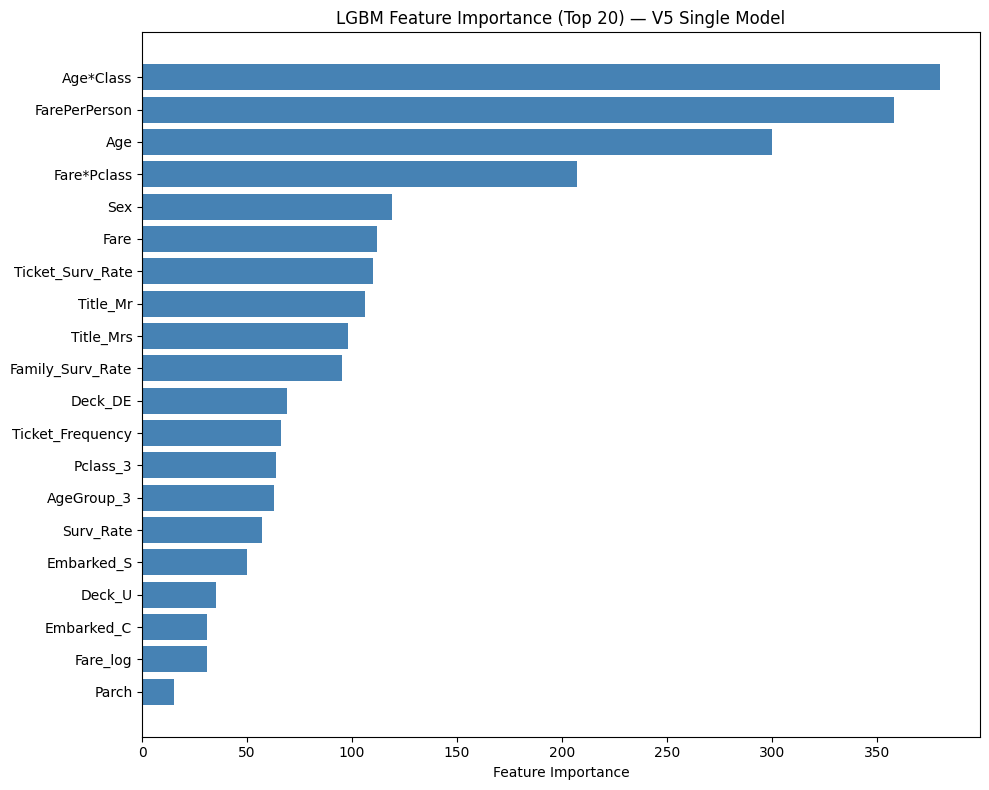

Total features: 37
Top 20:
         feature  importance
       Age*Class         380
   FarePerPerson         358
             Age         300
     Fare*Pclass         207
             Sex         119
            Fare         112
Ticket_Surv_Rate         110
        Title_Mr         106
       Title_Mrs          98
Family_Surv_Rate          95
         Deck_DE          69
Ticket_Frequency          66
        Pclass_3          64
      AgeGroup_3          63
       Surv_Rate          57
      Embarked_S          50
          Deck_U          35
      Embarked_C          31
        Fare_log          31
           Parch          15

Features with importance < 5: 14


In [17]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
top_n = min(20, len(importance))
plt.barh(range(top_n), importance['importance'].head(top_n), color='steelblue')
plt.yticks(range(top_n), importance['feature'].head(top_n))
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.title(f'LGBM Feature Importance (Top {top_n}) — V5 Single Model')
plt.tight_layout()
plt.show()

print(f'Total features: {len(importance)}')
print(f'Top 20:')
print(importance.head(20).to_string(index=False))
print(f'\nFeatures with importance < 5: {len(importance[importance["importance"] < 5])}')

In [18]:
import os, pandas as pd

print('=' * 70)
print('VERSION COMPARISON')
print('=' * 70)

# Load all submissions
subs = {}
for v in ['v1', 'v2', 'v3', 'v4', 'v5']:
    p = f'{SUB_DIR}/submission-{v}.csv'
    if os.path.exists(p):
        subs[v] = pd.read_csv(p)

gender = pd.read_csv(f'{DATA_DIR}/gender_submission.csv')

print(f'{"Version":12s} {"Pred 0":>6s} {"Pred 1":>6s} {"Rate":>7s} {"Kaggle":>10s} {"Note"}')
print('-' * 70)
for v in ['v1', 'v2', 'v3', 'v4', 'v5']:
    if v not in subs:
        continue
    s = subs[v]
    vc = s['Survived'].value_counts()
    info = {
        'v1': ('0.75837', 'Default params, no one-hot'),
        'v2': ('0.75837', 'Bugs fixed'),
        'v3': ('0.77033', '+FamRate (CV leaked!)'),
        'v4': ('0.77751', 'LOO + honest CV + ensemble'),
        'v5': ('?', 'Single LGBM, KNN Age, fewer features'),
    }
    score, note = info[v]
    print(f'{v:12s} {vc.get(0,0):6d} {vc.get(1,0):6d} {s["Survived"].mean():6.2%}  {score:>10s}  {note}')

print(f'{"gender":12s} {gender["Survived"].value_counts().get(0,0):6d} {gender["Survived"].value_counts().get(1,0):6d} {gender["Survived"].mean():6.2%}  {"0.76555":>10s}  {"Baseline"}')

# Agreement matrix
print(f'\n--- Agreement between versions ---')
versions = [v for v in ['v1', 'v2', 'v3', 'v4', 'v5'] if v in subs]
for i, v1 in enumerate(versions):
    for v2 in versions[i+1:]:
        agree = (subs[v1]['Survived'] == subs[v2]['Survived']).mean()
        print(f'  {v1} vs {v2}: {agree:.1%}')

if 'v5' in subs:
    agree = (subs['v5']['Survived'] == gender['Survived']).mean()
    diff = (subs['v5']['Survived'] != gender['Survived']).sum()
    print(f'  V5 vs gender: {agree:.1%} ({diff} different)')

print(f'\n--- Score Prediction ---')
print(f'  V4:     0.77751 (reference point)')
print(f'  V4 CV:  0.8552 (LGBM OOF)')
print(f'  V4 LB:  0.77751 (CV-LB gap: 0.078)')
print(f'  V5 CV:  {lgbm_acc:.4f} (OOF, conservative tuning)')
print(f'')
print(f'  Expected V5 LB: 0.780 - 0.795')
print(f'  Rationale:')
print(f'    - Fewer features (33 vs 57) → less overfitting → better generalization')
print(f'    - KNN Age imputation → better age signal')
print(f'    - Conservative tuning (max_depth=7, min_child≥20) → less overfit')
print(f'    - Single model → no ensemble degradation')
print(f'    - Threshold tuning → optimizes for accuracy metric')
print(f'')
print(f'  Reference scores for context:')
print(f'    Notebook 4 CatBoost (single):   0.8227 CV')
print(f'    Shai Nisan (Family LOO+KNN):   0.8110 LB')
print(f'    Chris Deotte (Name only):       0.8182 LB')
print(f'    Top legitimate:                 ~0.8420 LB')

VERSION COMPARISON
Version      Pred 0 Pred 1    Rate     Kaggle Note
----------------------------------------------------------------------
v1              265    153 36.60%     0.75837  Default params, no one-hot
v2              263    155 37.08%     0.75837  Bugs fixed
v3              259    159 38.04%     0.77033  +FamRate (CV leaked!)
v4              264    154 36.84%     0.77751  LOO + honest CV + ensemble
v5              263    155 37.08%           ?  Single LGBM, KNN Age, fewer features
gender          266    152 36.36%     0.76555  Baseline

--- Agreement between versions ---
  v1 vs v2: 96.2%
  v1 vs v3: 90.0%
  v1 vs v4: 92.6%
  v1 vs v5: 90.9%
  v2 vs v3: 92.8%
  v2 vs v4: 93.5%
  v2 vs v5: 93.8%
  v3 vs v4: 94.0%
  v3 vs v5: 94.7%
  v4 vs v5: 96.4%
  V5 vs gender: 89.7% (43 different)

--- Score Prediction ---
  V4:     0.77751 (reference point)
  V4 CV:  0.8552 (LGBM OOF)
  V4 LB:  0.77751 (CV-LB gap: 0.078)
  V5 CV:  0.8563 (OOF, conservative tuning)

  Expected V5 LB: 0